<a href="https://colab.research.google.com/github/mirandapachini/Advanced-Analytical-Tools/blob/main/Assignment_1%2C_2_%26_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split, KFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/MSBA 645 Machine Learning/higher+education+students+performance+evaluation.zip"
extract_path = "/content/student_data" # Changed extraction path to /content/

# Ensure the extraction directory exists
os.makedirs(extract_path, exist_ok=True)

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction completed. Files extracted to:", extract_path)
except FileNotFoundError:
    print(f"Error: The file {zip_path} was not found. Please ensure it's downloaded or uploaded.")
except zipfile.BadZipFile:
    print(f"Error: {zip_path} is not a valid zip file. Please check the downloaded file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Extraction completed. Files extracted to: /content/student_data


In [ ]:
import os

extract_path = "/content/student_data"

if os.path.exists(extract_path):
    print(f"Contents of {extract_path}:")
    for item in os.listdir(extract_path):
        print(os.path.join(extract_path, item))
else:
    print(f"The directory {extract_path} does not exist. Extraction might have failed.")

Contents of /content/student_data:
/content/student_data/DATA (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/student_data/DATA (1).csv')
print("DataFrame loaded successfully. First 5 rows:")
print(df.head())

DataFrame loaded successfully. First 5 rows:
  STUDENT ID  1  2  3  4  5  6  7  8  9  ...  23  24  25  26  27  28  29  30  \
0   STUDENT1  2  2  3  3  1  2  2  1  1  ...   1   1   3   2   1   2   1   1   
1   STUDENT2  2  2  3  3  1  2  2  1  1  ...   1   1   3   2   3   2   2   3   
2   STUDENT3  2  2  2  3  2  2  2  2  4  ...   1   1   2   2   1   1   2   2   
3   STUDENT4  1  1  1  3  1  2  1  2  1  ...   1   2   3   2   2   1   3   2   
4   STUDENT5  2  2  1  3  2  2  1  3  1  ...   2   1   2   2   2   1   2   2   

   COURSE ID  GRADE  
0          1      1  
1          1      1  
2          1      1  
3          1      1  
4          1      1  

[5 rows x 33 columns]


In [ ]:
import os

os.listdir("/content/student_data")

['DATA (1).csv']

In [ ]:
import pandas as pd

df = pd.read_csv("/content/student_data/DATA (1).csv")
df.head()

,STUDENT ID,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,...,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,...,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,...,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,...,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,...,2,1,2,2,2,1,2,2,1,1


In [ ]:
df.shape
df.columns

Index(['STUDENT ID', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', 'COURSE ID', 'GRADE'],
      dtype='object')

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   STUDENT ID  145 non-null    object
 1   1           145 non-null    int64 
 2   2           145 non-null    int64 
 3   3           145 non-null    int64 
 4   4           145 non-null    int64 
 5   5           145 non-null    int64 
 6   6           145 non-null    int64 
 7   7           145 non-null    int64 
 8   8           145 non-null    int64 
 9   9           145 non-null    int64 
 10  10          145 non-null    int64 
 11  11          145 non-null    int64 
 12  12          145 non-null    int64 
 13  13          145 non-null    int64 
 14  14          145 non-null    int64 
 15  15          145 non-null    int64 
 16  16          145 non-null    int64 
 17  17          145 non-null    int64 
 18  18          145 non-null    int64 
 19  19          145 non-null    int64 
 20  20        

,1,2,3,4,5,6,7,8,9,10,...,23,24,25,26,27,28,29,30,COURSE ID,GRADE
count,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,...,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000
mean,1.620690,1.600000,1.944828,3.572414,1.662069,1.600000,1.579310,1.627586,1.620690,1.731034,...,1.337931,1.165517,2.544828,2.055172,2.393103,1.806897,3.124138,2.724138,4.131034,3.227586
std,0.613154,0.491596,0.537216,0.805750,0.474644,0.491596,0.495381,1.020245,1.061112,0.783999,...,0.614870,0.408483,0.564940,0.674736,0.604343,0.810492,1.301083,0.916536,3.260145,2.197678
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,...,1.000000,1.000000,3.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,1.000000,3.000000,3.000000,3.000000,2.000000,4.000000,3.000000,7.000000,5.000000
max,3.000000,2.000000,3.000000,5.000000,2.000000,2.000000,2.000000,5.000000,4.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,5.000000,4.000000,9.000000,7.000000


In [ ]:
df.isna().sum()

,0
STUDENT ID,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [ ]:
df.dtypes

,0
STUDENT ID,object
1,int64
2,int64
3,int64
4,int64
5,int64
6,int64
7,int64
8,int64
9,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   STUDENT ID  145 non-null    object
 1   1           145 non-null    int64 
 2   2           145 non-null    int64 
 3   3           145 non-null    int64 
 4   4           145 non-null    int64 
 5   5           145 non-null    int64 
 6   6           145 non-null    int64 
 7   7           145 non-null    int64 
 8   8           145 non-null    int64 
 9   9           145 non-null    int64 
 10  10          145 non-null    int64 
 11  11          145 non-null    int64 
 12  12          145 non-null    int64 
 13  13          145 non-null    int64 
 14  14          145 non-null    int64 
 15  15          145 non-null    int64 
 16  16          145 non-null    int64 
 17  17          145 non-null    int64 
 18  18          145 non-null    int64 
 19  19          145 non-null    int64 
 20  20        

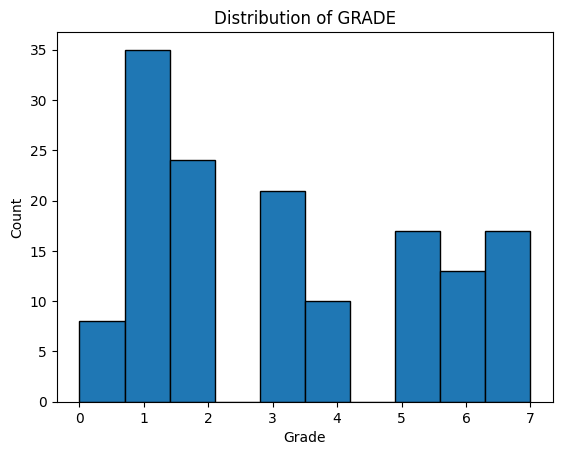

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['GRADE'], bins=10, edgecolor='black')
plt.title('Distribution of GRADE')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

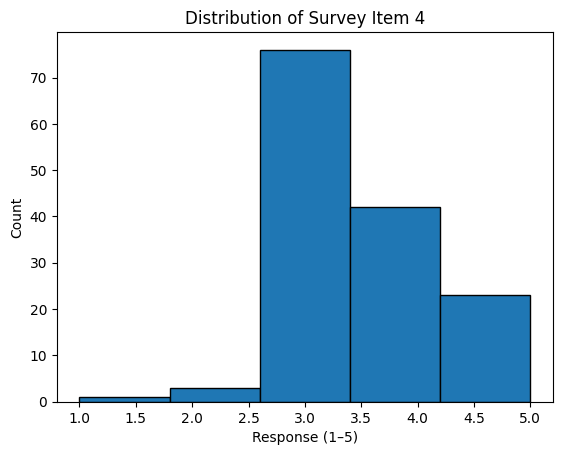

In [ ]:
plt.hist(df['4'], bins=5, edgecolor='black')
plt.title('Distribution of Survey Item 4')
plt.xlabel('Response (1–5)')
plt.ylabel('Count')
plt.show()

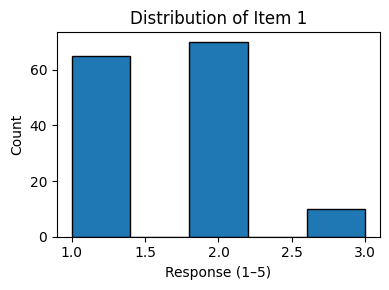

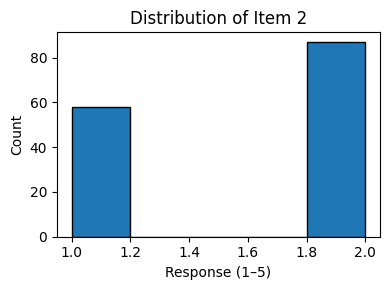

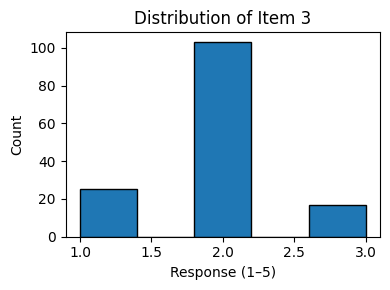

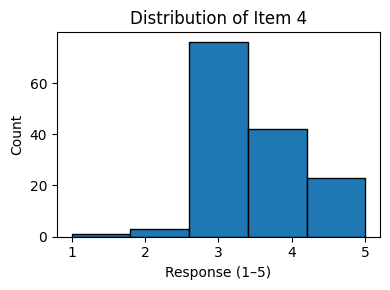

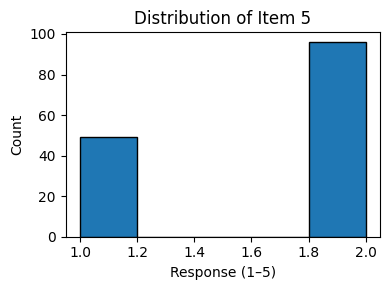

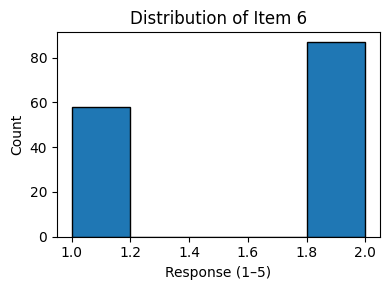

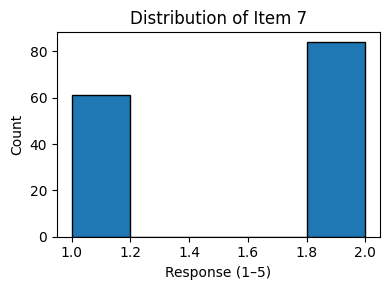

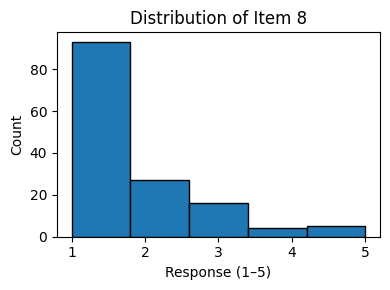

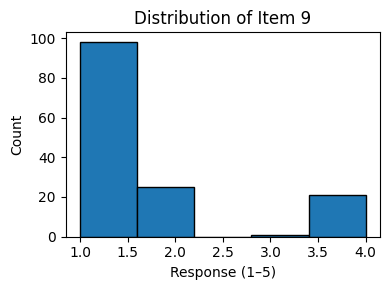

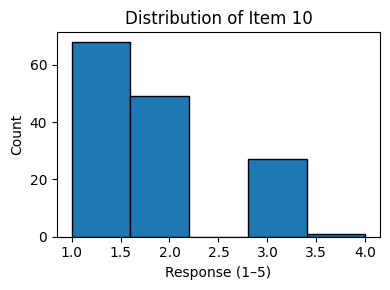

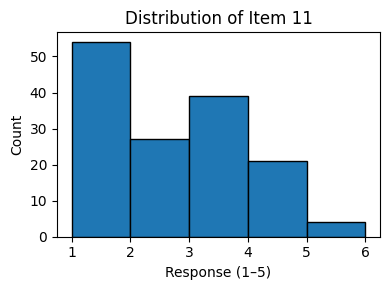

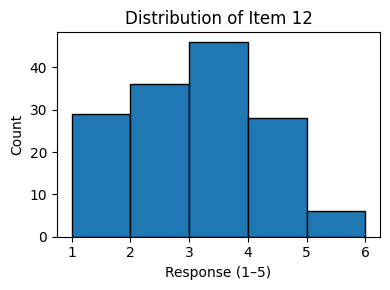

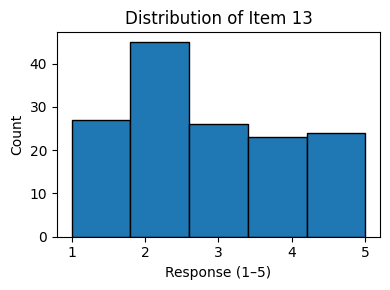

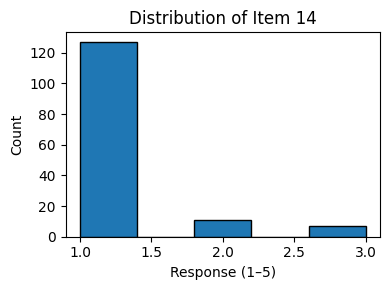

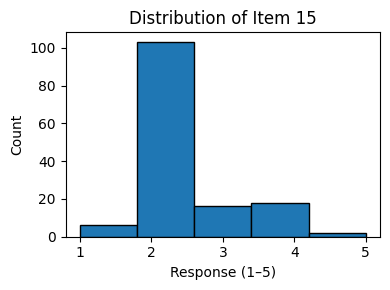

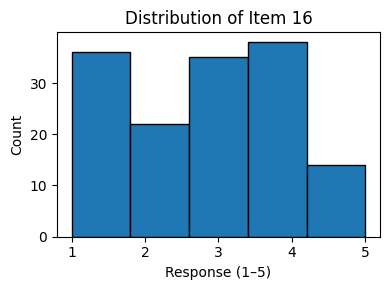

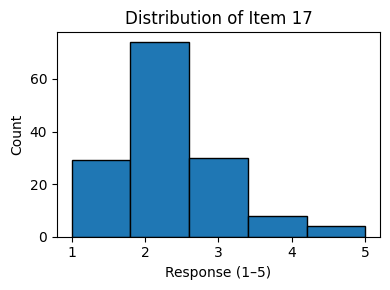

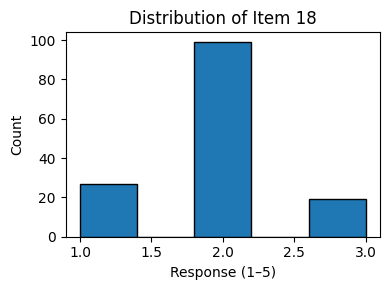

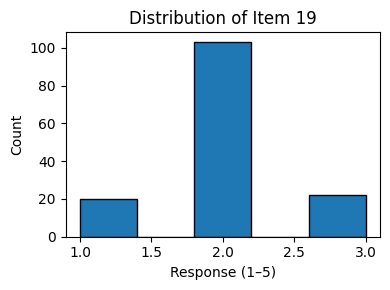

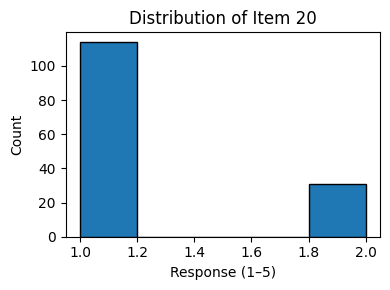

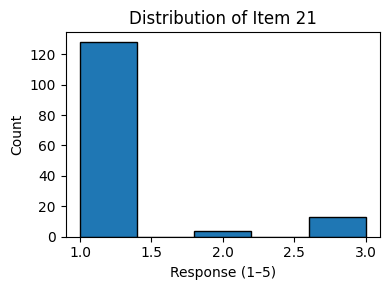

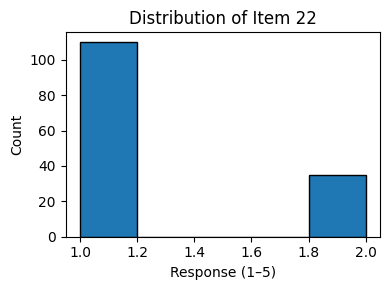

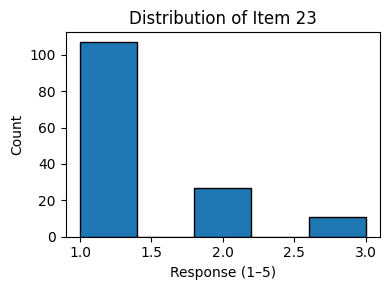

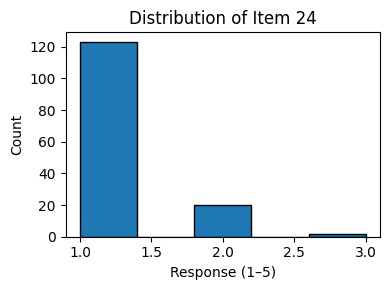

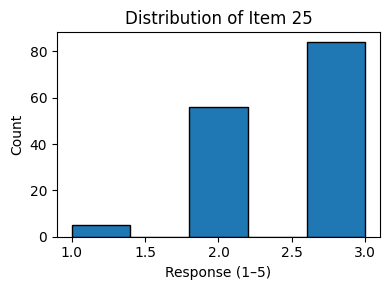

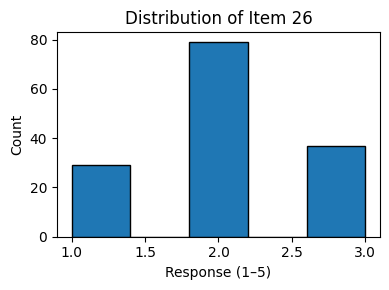

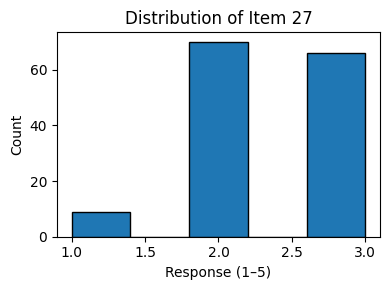

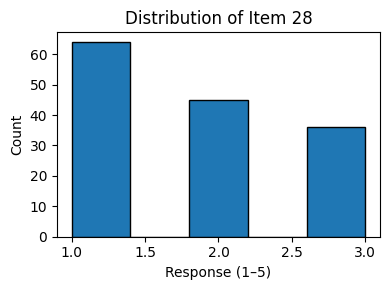

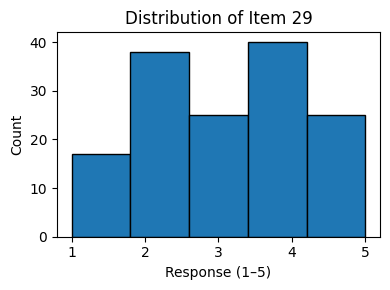

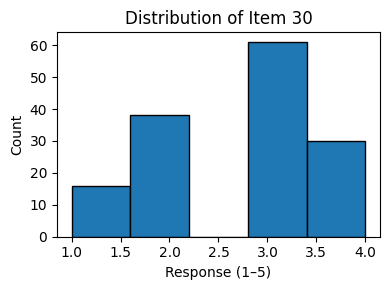

In [ ]:
import matplotlib.pyplot as plt

cols = [str(i) for i in range(1, 31)]

for col in cols:
    plt.figure(figsize=(4,3))
    plt.hist(df[col], bins=5, edgecolor='black')
    plt.title(f'Distribution of Item {col}')
    plt.xlabel('Response (1–5)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

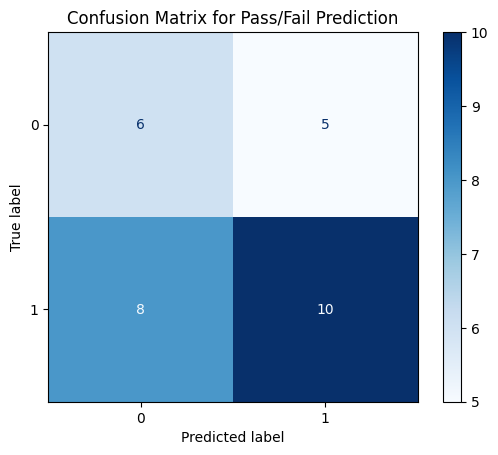

In [ ]:
df['PassFlag'] = (df['GRADE'] >= 3).astype(int)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# IVs = survey items 1–30
X = df[[str(i) for i in range(1, 31)]]
y = df['PassFlag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Pass/Fail Prediction")
plt.show()


In [ ]:
corr = df.drop(columns=['STUDENT ID']).corr()
corr

corr['GRADE'].sort_values(ascending=False)

,GRADE
GRADE,1.000000
PassFlag,0.841619
2,0.335533
29,0.315493
30,0.248588
18,0.195617
5,0.167445
27,0.146547
COURSE ID,0.142166
28,0.110617


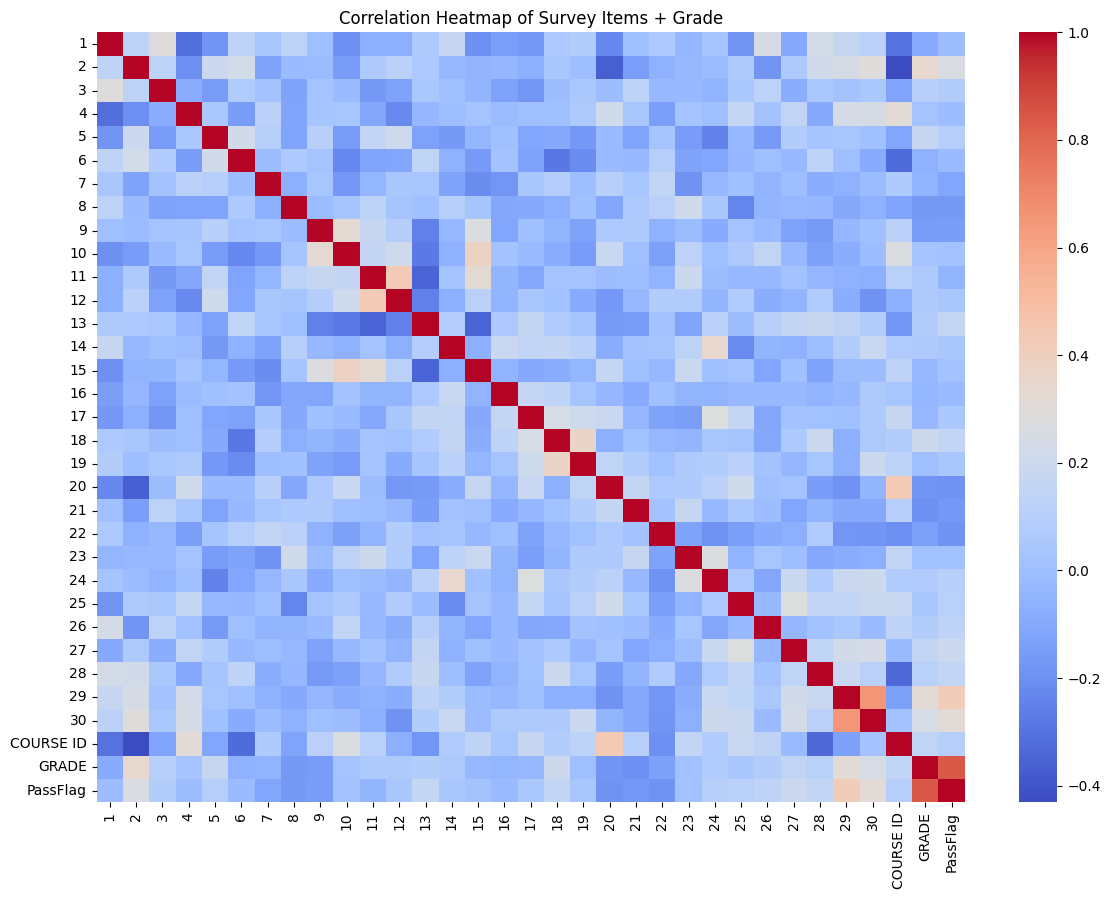

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.heatmap(df.drop(columns=['STUDENT ID']).corr(),
            cmap='coolwarm',
            annot=False)
plt.title("Correlation Heatmap of Survey Items + Grade")
plt.show()

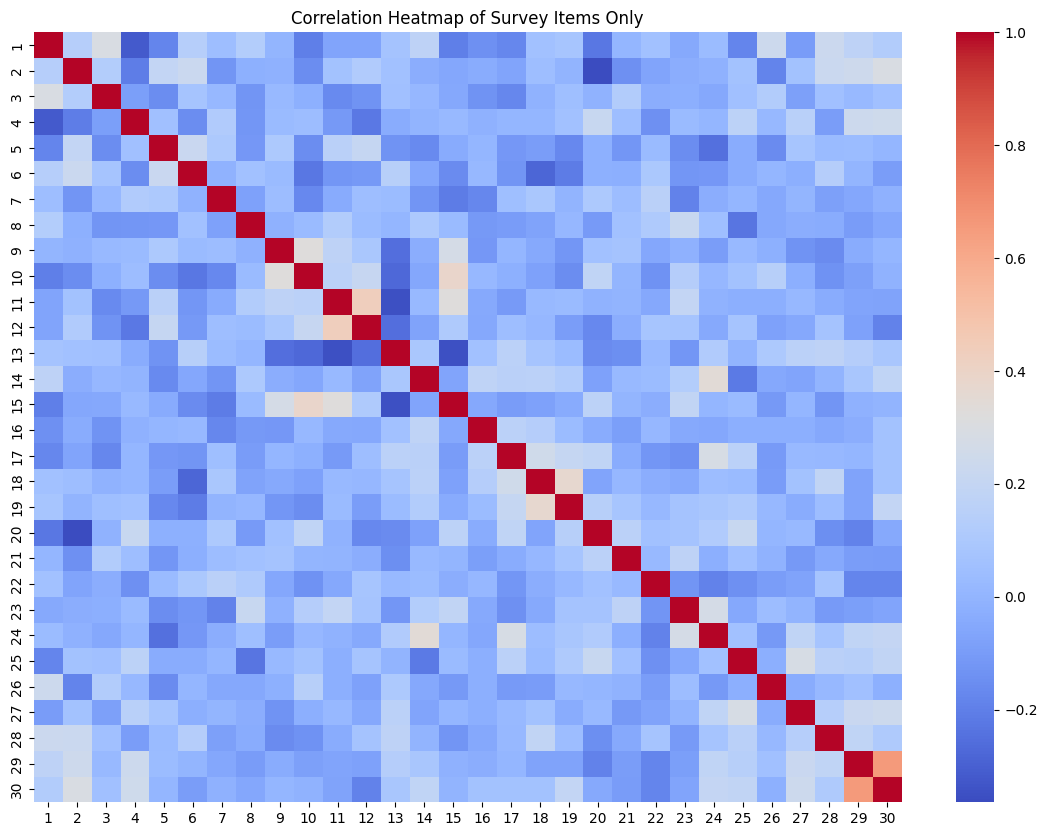

In [ ]:
survey_cols = [str(i) for i in range(1, 31)]

plt.figure(figsize=(14, 10))
sns.heatmap(df[survey_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Survey Items Only")
plt.show()

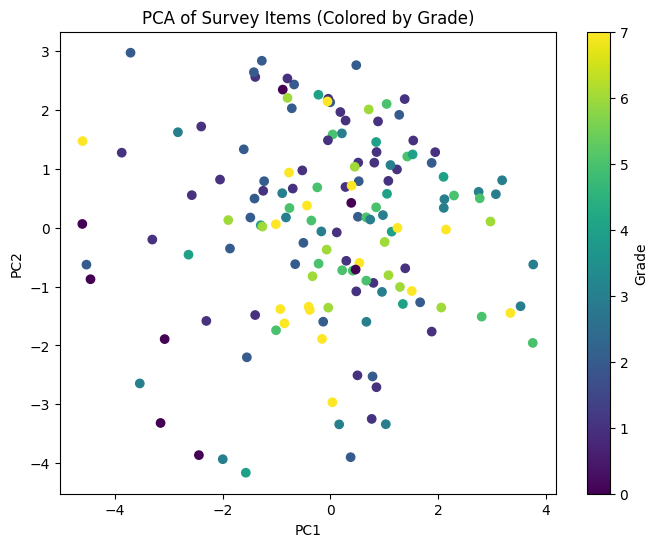

array([0.09981571, 0.08450832])

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

survey_cols = [str(i) for i in range(1, 31)]
X = df[survey_cols]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['GRADE'], cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Survey Items (Colored by Grade)")
plt.colorbar(label='Grade')
plt.show()

pca.explained_variance_ratio_

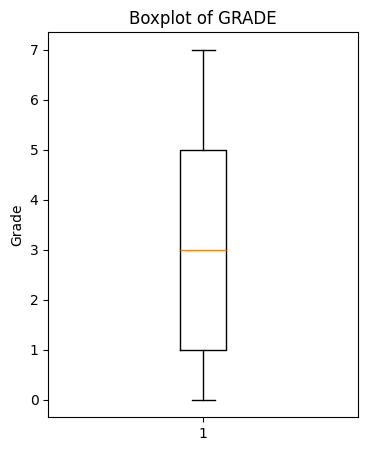

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,5))
plt.boxplot(df['GRADE'], vert=True)
plt.title("Boxplot of GRADE")
plt.ylabel("Grade")
plt.show()

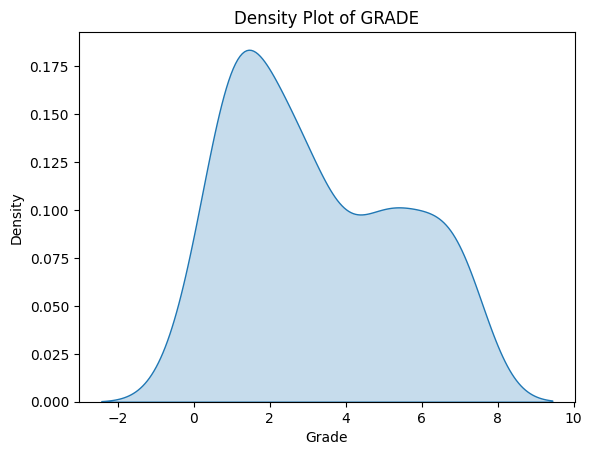

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df['GRADE'], shade=True)
plt.title("Density Plot of GRADE")
plt.xlabel("Grade")
plt.ylabel("Density")
plt.show()

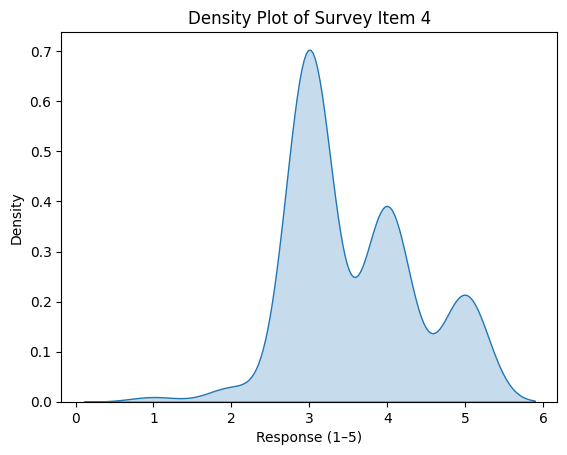

In [ ]:
sns.kdeplot(df['4'], shade=True)
plt.title("Density Plot of Survey Item 4")
plt.xlabel("Response (1–5)")
plt.ylabel("Density")
plt.show()

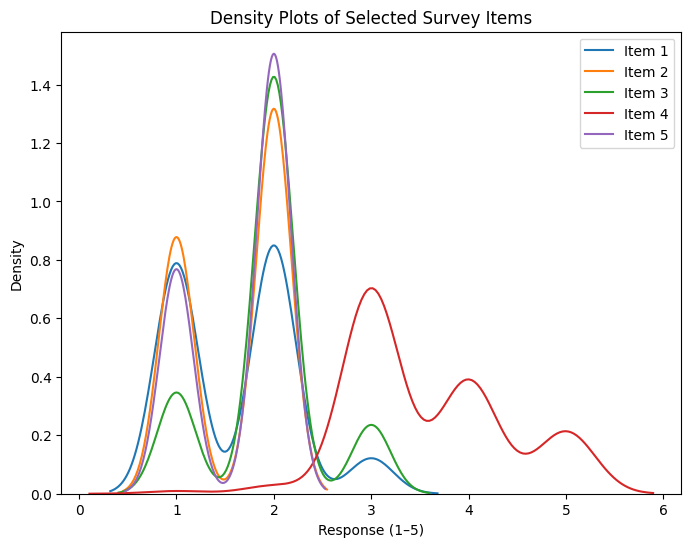

In [ ]:
survey_cols = ['1', '2', '3', '4', '5']

plt.figure(figsize=(8,6))
for col in survey_cols:
    sns.kdeplot(df[col], shade=False, label=f'Item {col}')

plt.title("Density Plots of Selected Survey Items")
plt.xlabel("Response (1–5)")
plt.ylabel("Density")
plt.legend()
plt.show()

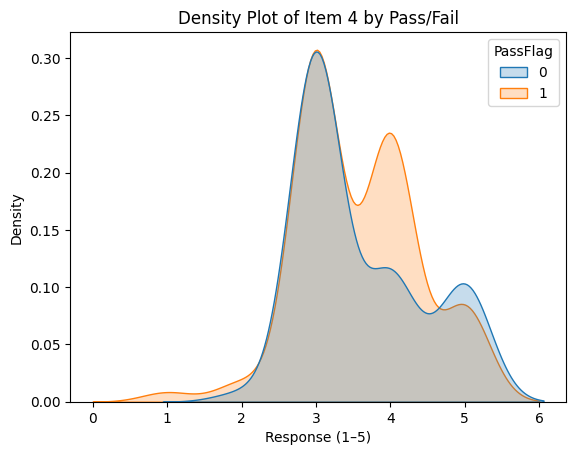

In [ ]:
df['PassFlag'] = (df['GRADE'] >= 3).astype(int)

sns.kdeplot(data=df, x='4', hue='PassFlag', shade=True)
plt.title("Density Plot of Item 4 by Pass/Fail")
plt.xlabel("Response (1–5)")
plt.ylabel("Density")
plt.show()

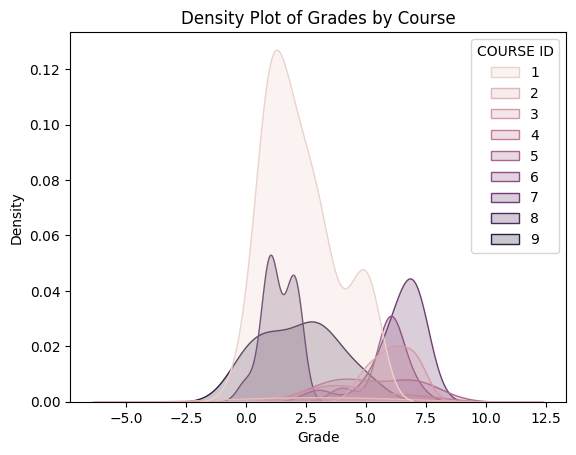

In [ ]:
sns.kdeplot(data=df, x='GRADE', hue='COURSE ID', shade=True)
plt.title("Density Plot of Grades by Course")
plt.xlabel("Grade")
plt.ylabel("Density")
plt.show()

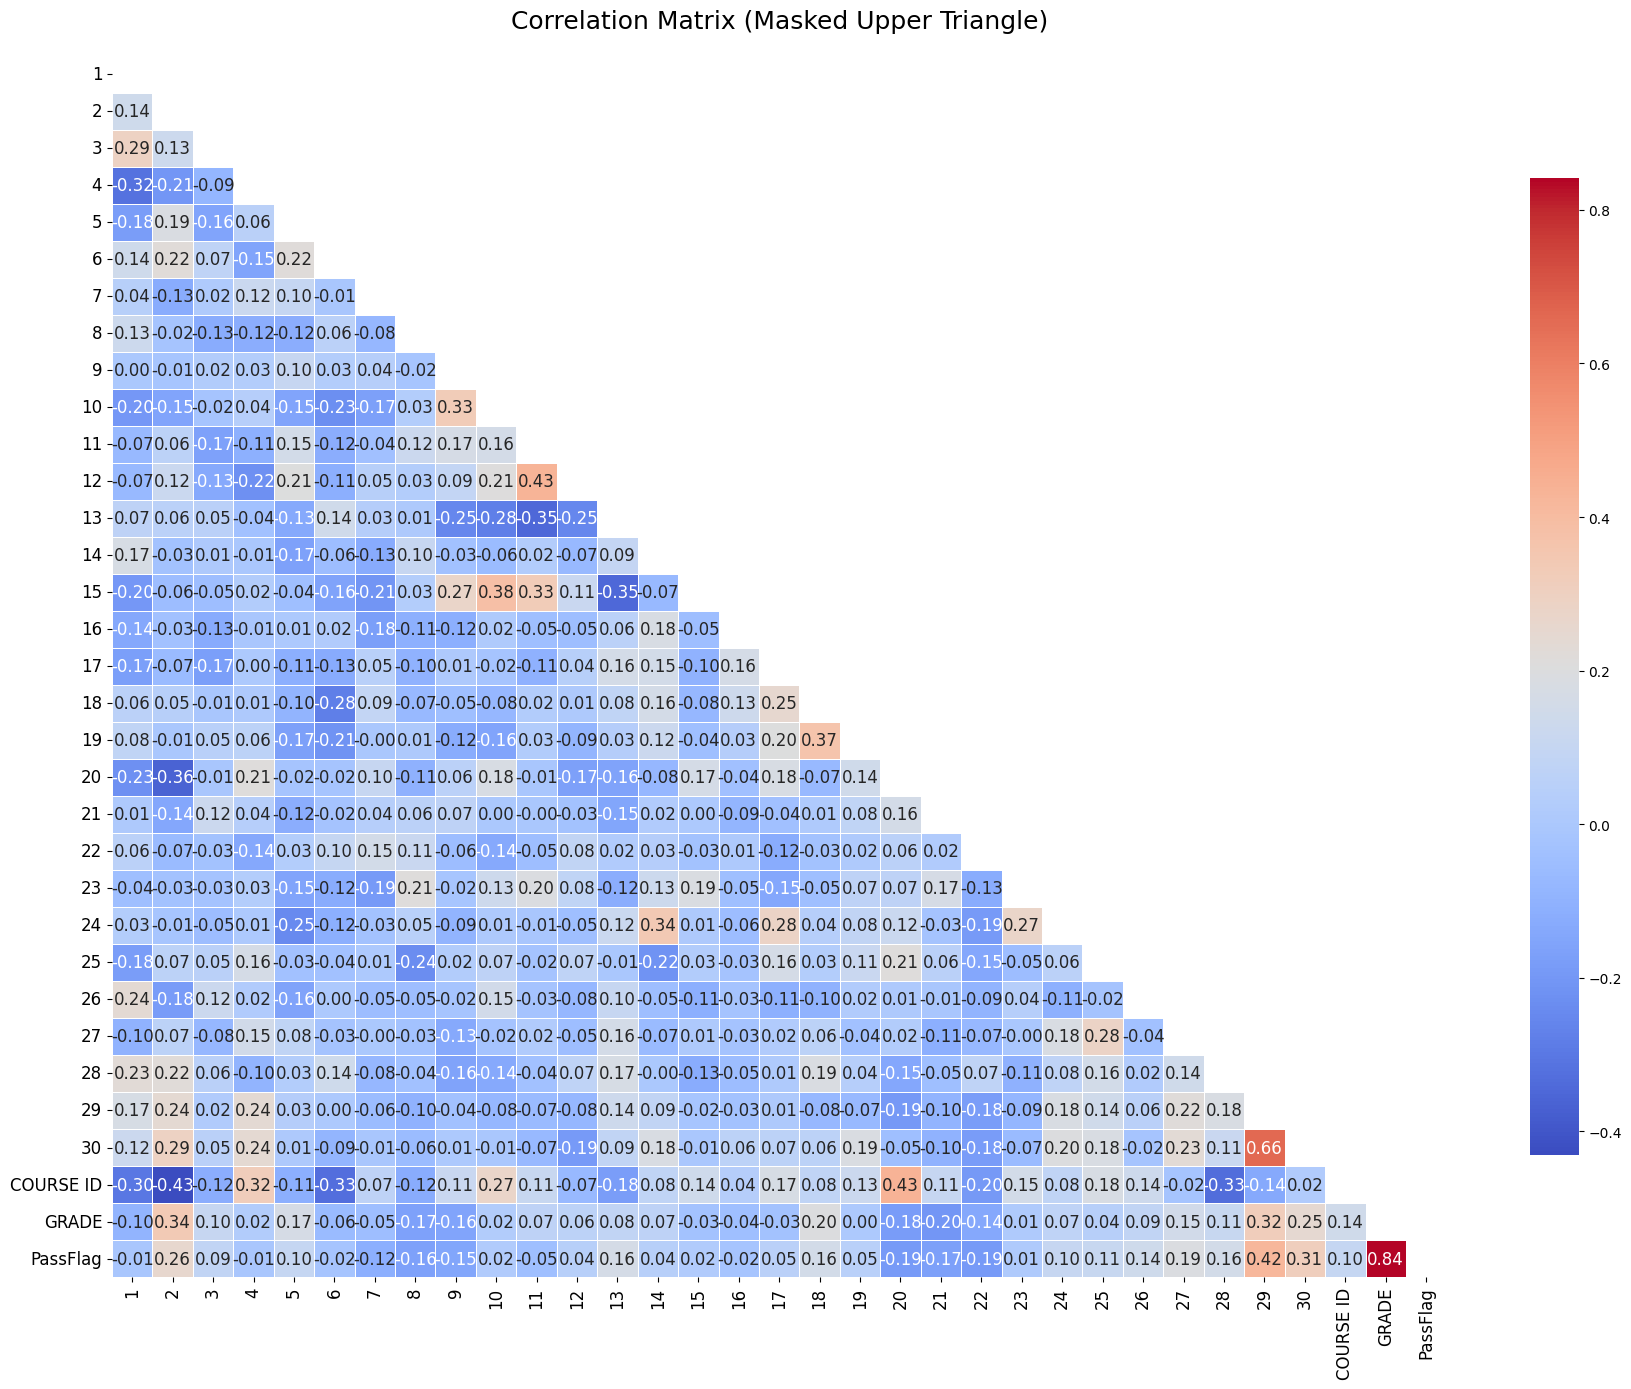

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix (drop ID column)
corr = df.drop(columns=['STUDENT ID']).corr()

# Mask upper triangle
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",                 # cleaner than percent formatting
    annot_kws={"size": 12},    # bigger annotation text
    linewidths=0.7,            # spacing between cells
    cbar_kws={"shrink": 0.8}   # smaller colorbar
)

plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.title("Correlation Matrix (Masked Upper Triangle)", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

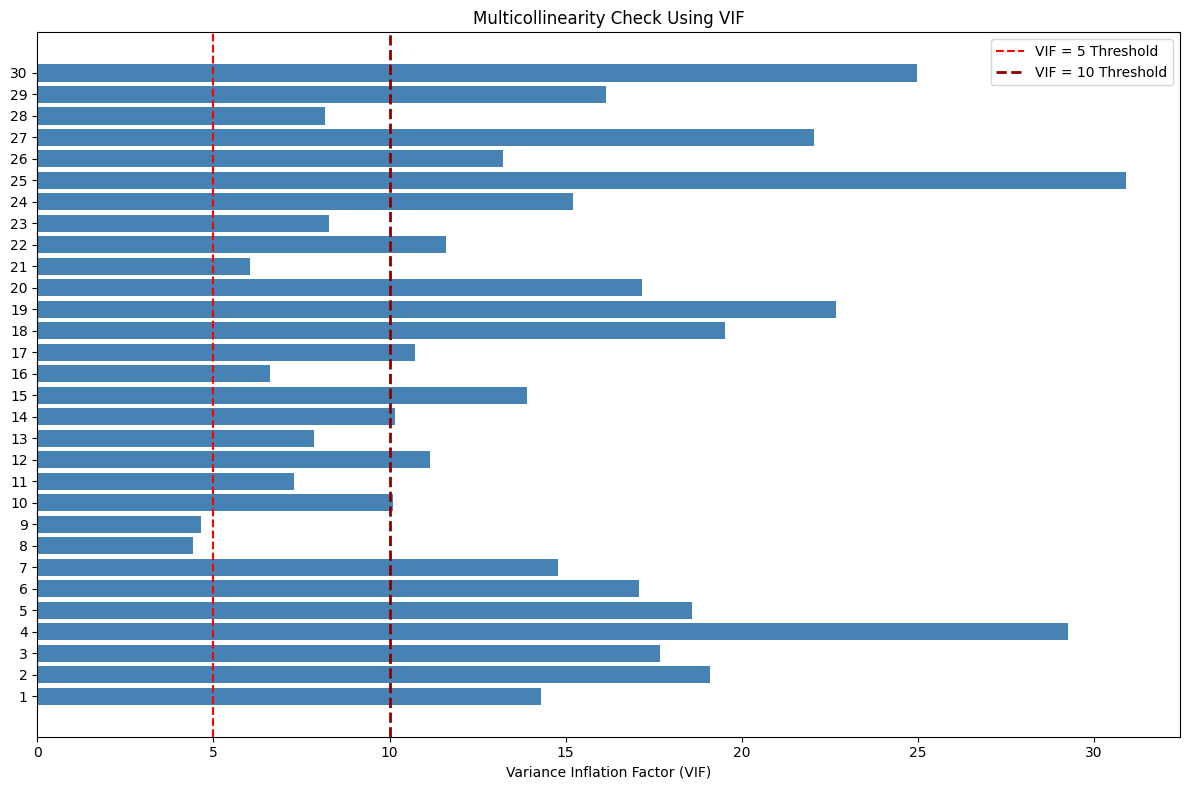

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numeric IVs (drop ID + target)
iv_cols = [str(i) for i in range(1, 31)]
X = df[iv_cols]

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

plt.figure(figsize=(12, 8))
plt.barh(vif_data["Variable"], vif_data["VIF"], color="steelblue")
plt.xlabel("Variance Inflation Factor (VIF)")
plt.title("Multicollinearity Check Using VIF")
plt.axvline(x=5, color='red', linestyle='--', label='VIF = 5 Threshold')
plt.axvline(x=10, color='darkred', linestyle='--', linewidth=2, label='VIF = 10 Threshold')

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

cluster_cols = [str(i) for i in range(1, 31)]
X = df[cluster_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

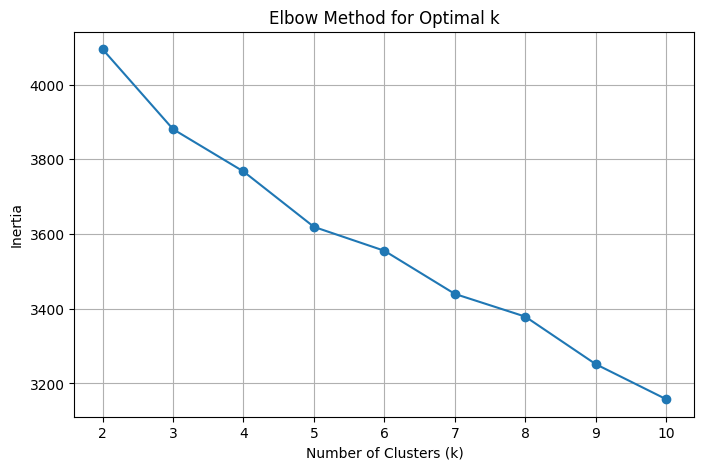

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

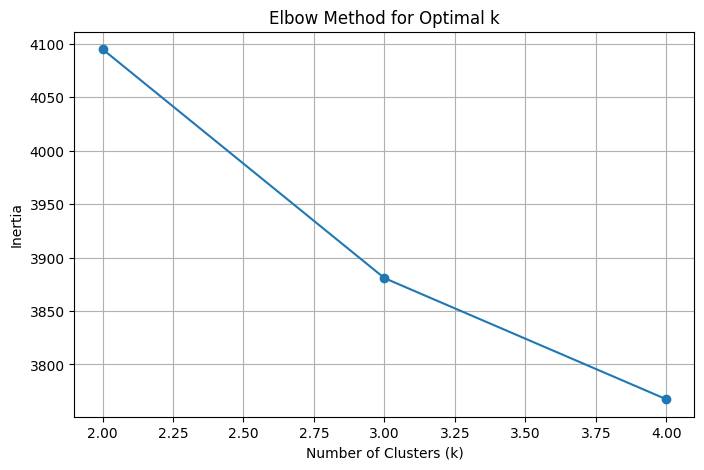

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K = range(2, 5)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

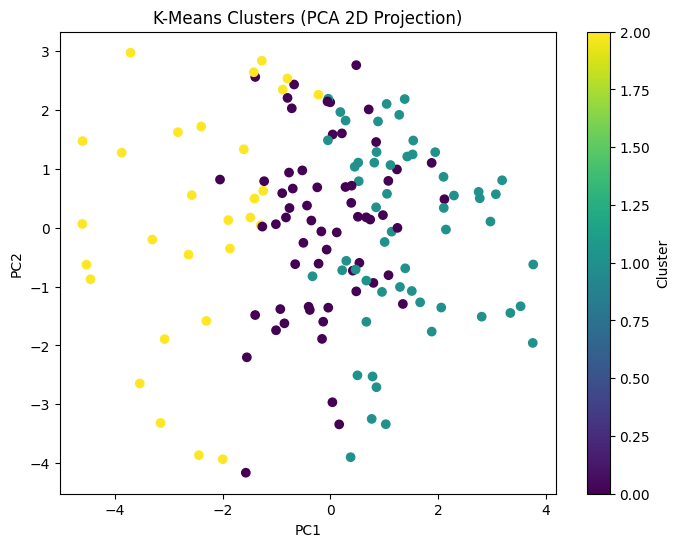

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA 2D Projection)")
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
from sklearn.cluster import KMeans

cluster_percentages = {}

n = len(X_scaled)   # total rows (corrected variable name)

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)

    counts = pd.Series(labels).value_counts().sort_index()
    percents = (counts / n * 100).round(2)

    cluster_percentages[k] = percents

cluster_percentages

{1: 0    100.0
 Name: count, dtype: float64,
 2: 0    54.48
 1    45.52
 Name: count, dtype: float64,
 3: 0    42.07
 1    37.93
 2    20.00
 Name: count, dtype: float64,
 4: 0    11.72
 1    28.28
 2    15.86
 3    44.14
 Name: count, dtype: float64,
 5: 0     9.66
 1    27.59
 2    13.79
 3    31.72
 4    17.24
 Name: count, dtype: float64,
 6: 0     1.38
 1    21.38
 2     7.59
 3    26.21
 4    15.17
 5    28.28
 Name: count, dtype: float64,
 7: 0     1.38
 1    13.79
 2     7.59
 3    24.14
 4    13.10
 5    17.93
 6    22.07
 Name: count, dtype: float64,
 8: 0     7.59
 1     7.59
 2    15.86
 3    11.72
 4    20.00
 5     3.45
 6    24.14
 7     9.66
 Name: count, dtype: float64,
 9: 0     4.14
 1     1.38
 2    16.55
 3     9.66
 4    22.07
 5     3.45
 6    19.31
 7    11.72
 8    11.72
 Name: count, dtype: float64,
 10: 0     4.14
 1     2.76
 2    15.17
 3    11.72
 4    18.62
 5     2.76
 6    11.72
 7    10.34
 8    11.03
 9    11.72
 Name: count, dtype: float64}

In [ ]:
cluster_labels = {
    0: "High Engagement / High GPA",
    1: "Moderate Engagement / Moderate GPA",
    2: "Low Engagement / Low GPA"
}

df["ClusterLabel"] = df["Cluster"].map(cluster_labels)

In [ ]:
df.groupby('Cluster')[cluster_cols].mean()

,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.508197,1.868852,1.918033,3.655738,1.901639,1.606557,1.590164,1.360656,1.803279,1.704918,...,1.081967,1.114754,1.295082,1.081967,2.622951,1.901639,2.508197,1.754098,3.377049,2.950820
1,1.781818,1.527273,2.054545,3.618182,1.454545,1.654545,1.636364,1.654545,1.163636,1.400000,...,1.145455,1.345455,1.200000,1.290909,2.545455,2.145455,2.418182,1.981818,3.363636,2.872727
2,1.551724,1.172414,1.793103,3.310345,1.551724,1.482759,1.448276,2.137931,2.103448,2.413793,...,1.586207,1.310345,1.689655,1.103448,2.379310,2.206897,2.103448,1.586207,2.137931,1.965517


In [ ]:
df.groupby('Cluster')['GRADE'].mean()

,GRADE
Cluster,
0,3.868852
1,3.181818
2,1.965517


In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# -----------------------------
# 1. Compute VIF for all IVs
# -----------------------------
iv_cols = [str(i) for i in range(1, 31)]
X = df[iv_cols]

vif_data = pd.DataFrame()
vif_data["IV"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# -----------------------------
# 2. Compute cluster centers
# -----------------------------
cluster_centers = df.groupby("Cluster")[iv_cols].mean()

# -----------------------------
# 3. Assign each IV to the cluster
#    where its mean value is highest
# -----------------------------
iv_cluster_map = {}

for iv in cluster_centers.columns:
    best_cluster = cluster_centers[iv].idxmax()
    iv_cluster_map[iv] = best_cluster

cluster_assignments = (
    pd.DataFrame.from_dict(iv_cluster_map, orient='index', columns=["Cluster"])
    .reset_index()
    .rename(columns={"index": "IV"})
)

# -----------------------------
# 4. Merge VIF + Cluster assignment
# -----------------------------
full_table = vif_data.merge(cluster_assignments, on="IV")

# -----------------------------
# 5. Add multicollinearity flag
# -----------------------------
def vif_flag(v):
    if v < 5:
        return "No multicollinearity"
    elif v < 10:
        return "Moderate multicollinearity"
    else:
        return "Severe multicollinearity"

full_table["Multicollinearity"] = full_table["VIF"].apply(vif_flag)

# -----------------------------
# 6. Filter only VIF > 10
# -----------------------------
high_vif_table = full_table[full_table["VIF"] > 10]

# Display both tables
full_table, high_vif_table

(    IV        VIF  Cluster           Multicollinearity
 0    1  14.295199        1    Severe multicollinearity
 1    2  19.115298        0    Severe multicollinearity
 2    3  17.673964        1    Severe multicollinearity
 3    4  29.278105        0    Severe multicollinearity
 4    5  18.592850        0    Severe multicollinearity
 5    6  17.077720        1    Severe multicollinearity
 6    7  14.780030        1    Severe multicollinearity
 7    8   4.427352        2        No multicollinearity
 8    9   4.651647        2        No multicollinearity
 9   10  10.107023        2    Severe multicollinearity
 10  11   7.284799        2  Moderate multicollinearity
 11  12  11.159476        2    Severe multicollinearity
 12  13   7.860608        1  Moderate multicollinearity
 13  14  10.142872        1    Severe multicollinearity
 14  15  13.910065        2    Severe multicollinearity
 15  16   6.606974        1  Moderate multicollinearity
 16  17  10.725670        1    Severe multicolli

In [ ]:
# Dataset with all IVs and Grade

iv_cols = [str(i) for i in range(1, 31)]
model_df_all = df[iv_cols + ["GRADE"]]

In [ ]:
# Dataset with only IVs with VIF < 10 and Grade

safe_iv_list = full_table[full_table["VIF"] < 10]["IV"].tolist()

model_df_vif_safe = df[safe_iv_list + ["GRADE"]]

In [ ]:
# Dataset with only my chosen IVs and Grade

final_iv_list = ["29", "22", "26", "17", "21", "24", "18", "19",
                    "23", "28", "11", "13"]

model_df_final= df[final_iv_list + ["GRADE"]]

In [ ]:
model_df_final.head()
model_df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   29      145 non-null    int64
 1   22      145 non-null    int64
 2   26      145 non-null    int64
 3   17      145 non-null    int64
 4   21      145 non-null    int64
 5   24      145 non-null    int64
 6   18      145 non-null    int64
 7   19      145 non-null    int64
 8   23      145 non-null    int64
 9   28      145 non-null    int64
 10  11      145 non-null    int64
 11  13      145 non-null    int64
 12  GRADE   145 non-null    int64
dtypes: int64(13)
memory usage: 14.9 KB


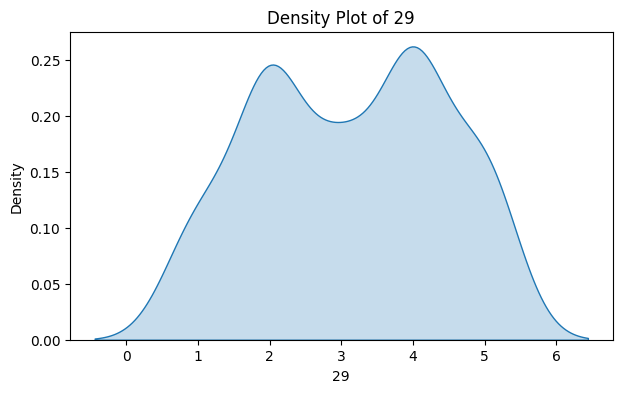

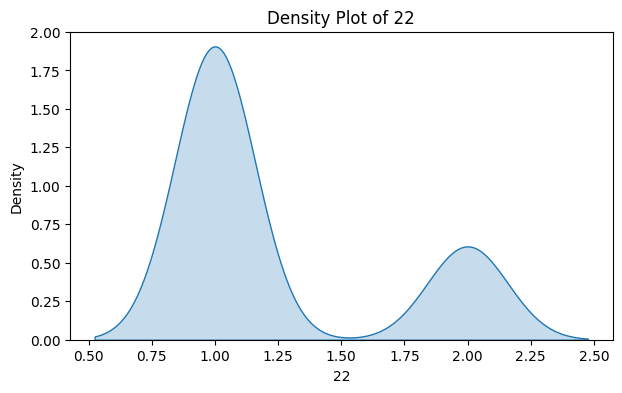

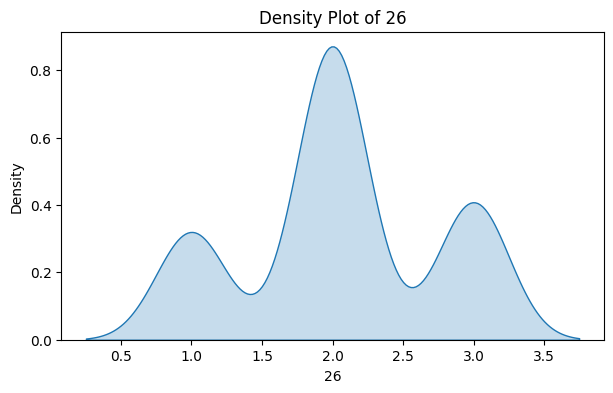

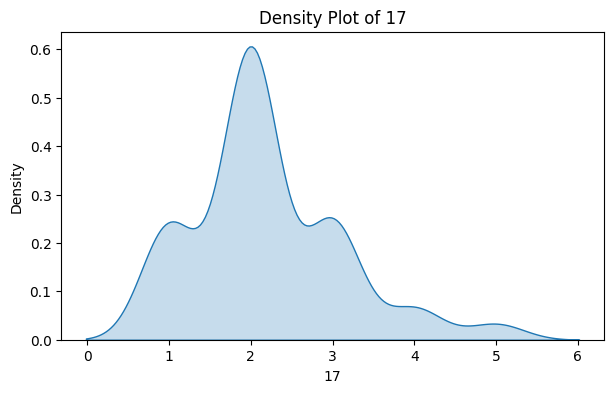

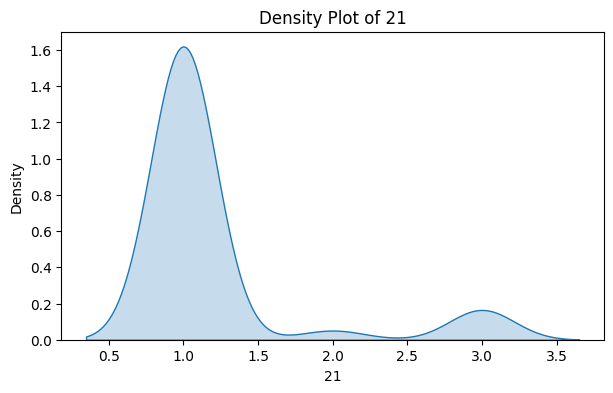

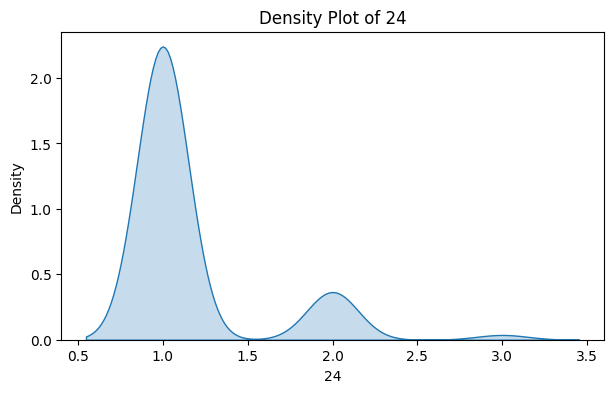

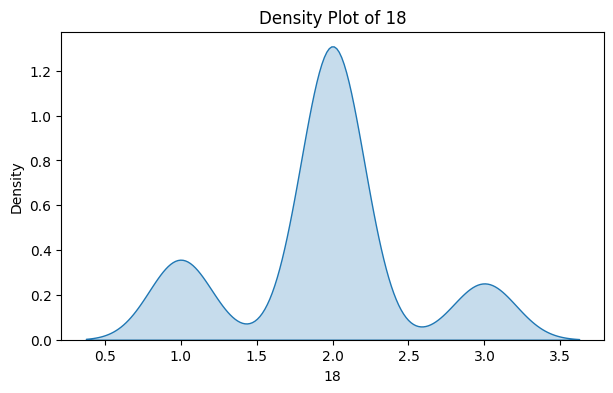

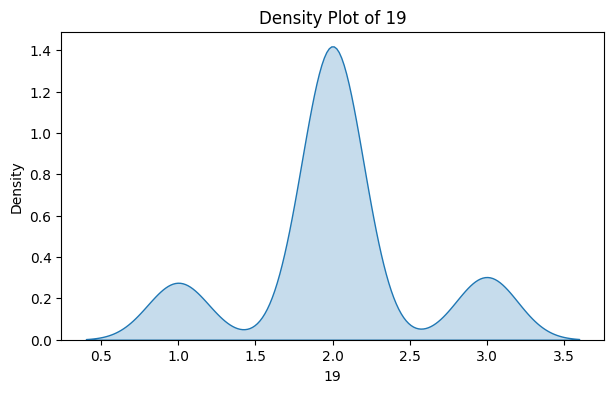

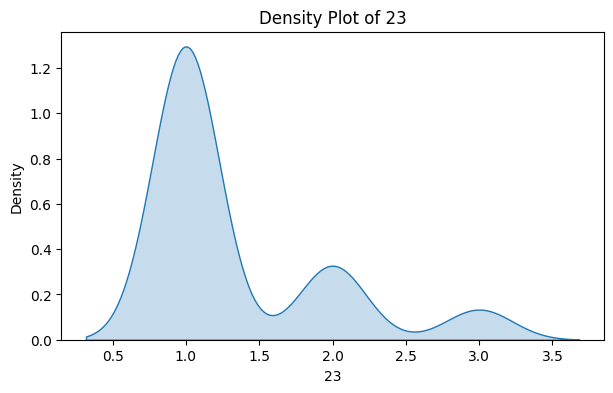

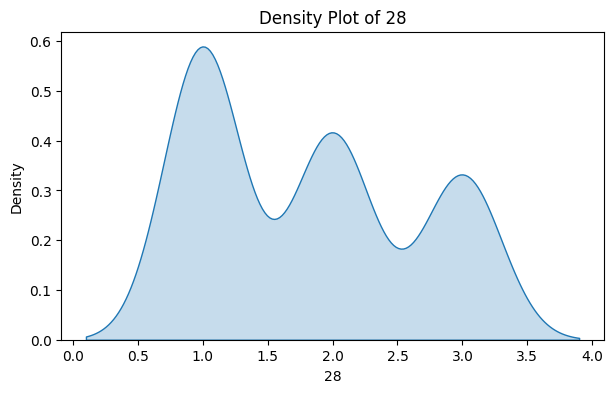

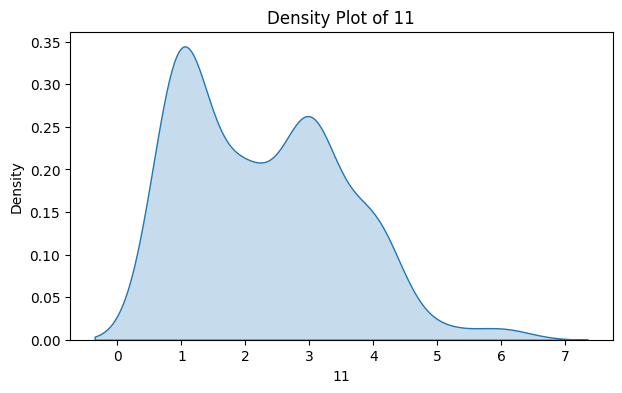

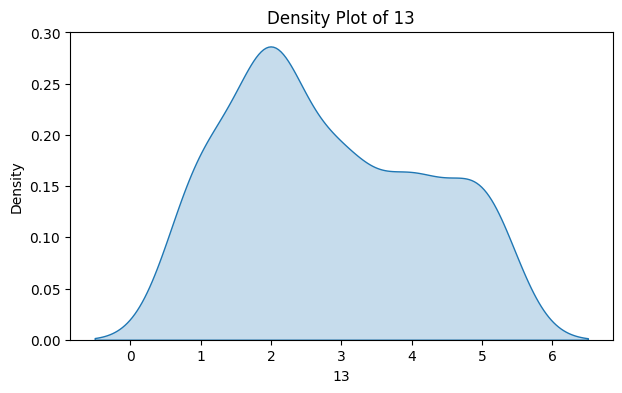

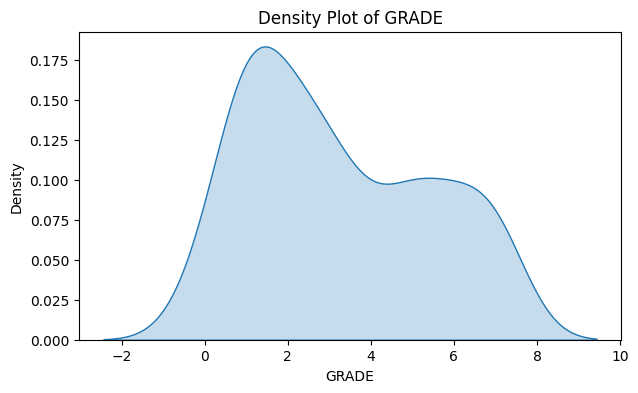

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in final_iv_list + ["GRADE"]:
    plt.figure(figsize=(7,4))
    sns.kdeplot(df[col], shade=True)
    plt.title(f"Density Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

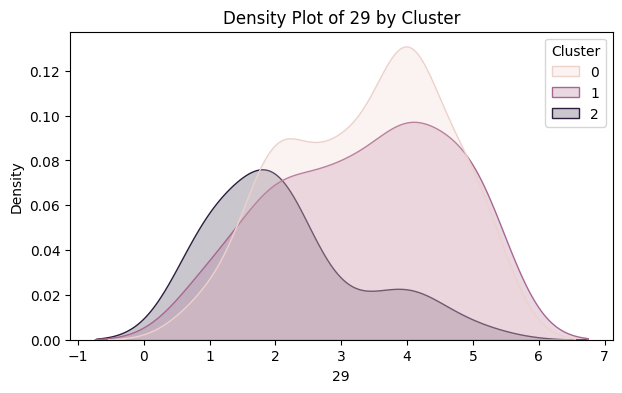

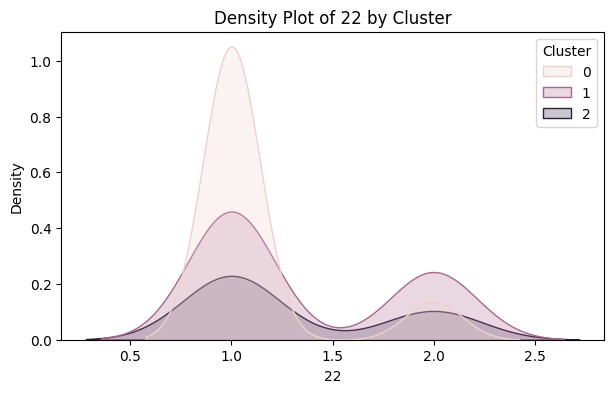

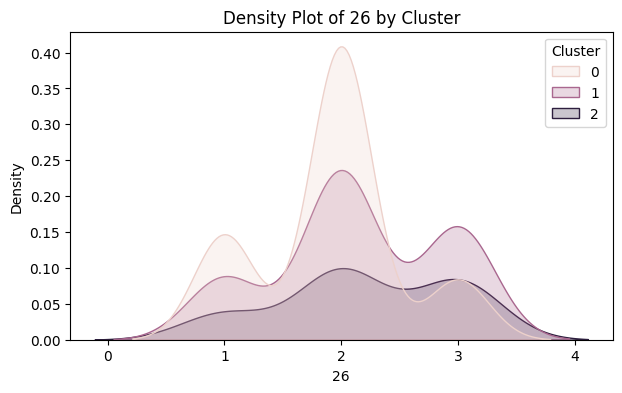

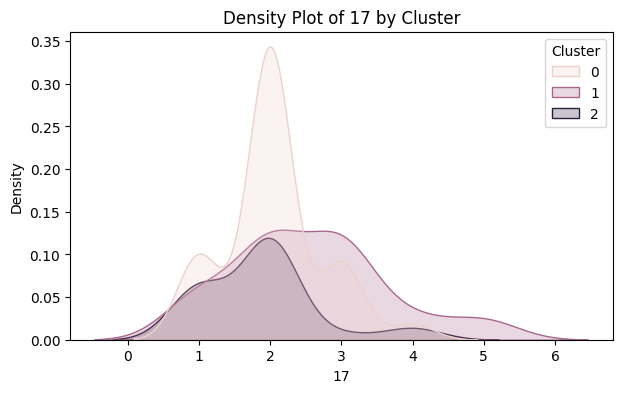

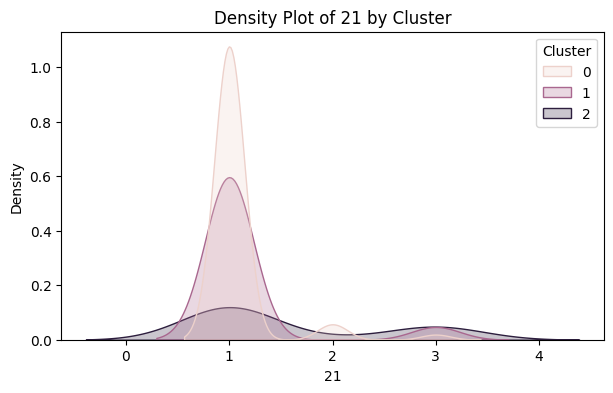

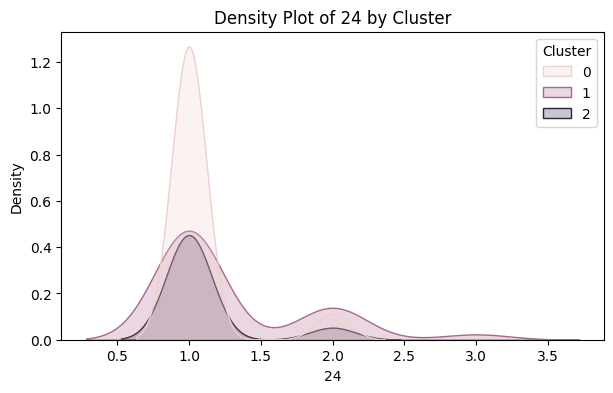

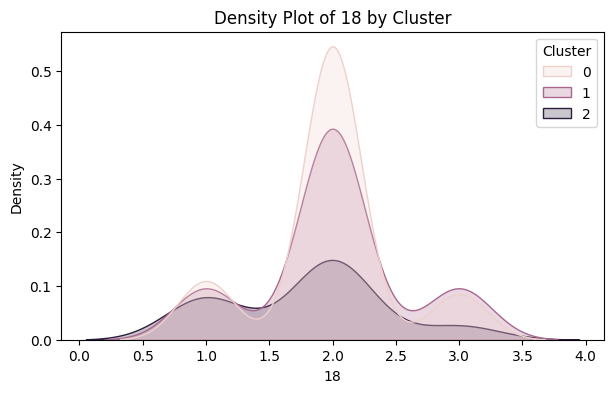

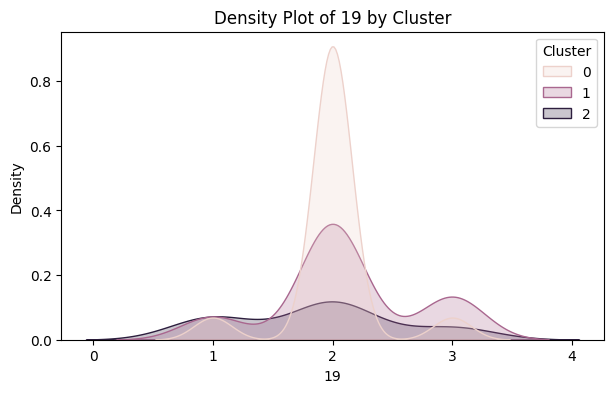

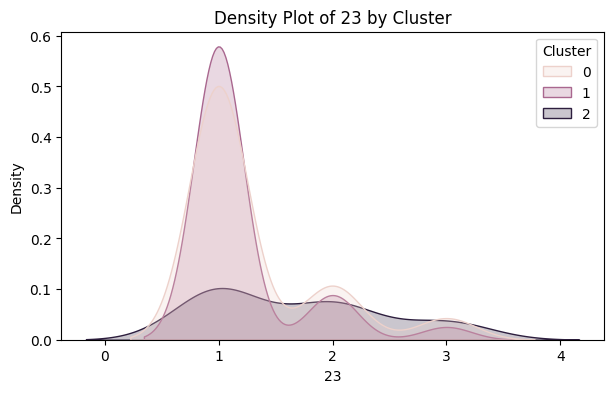

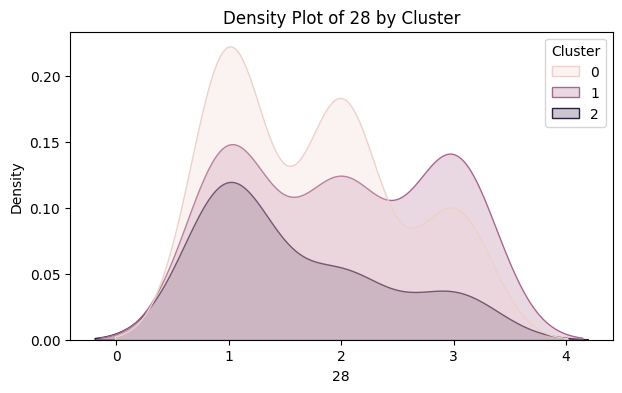

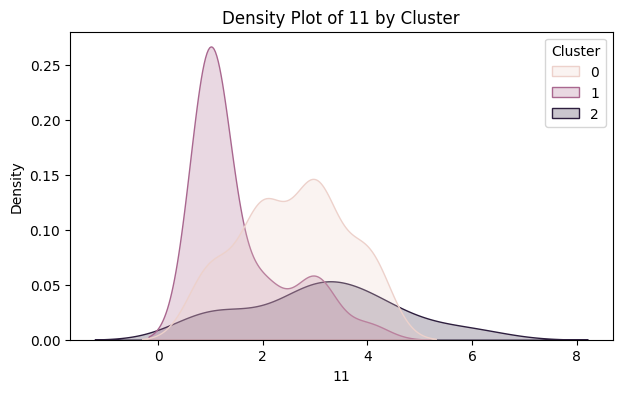

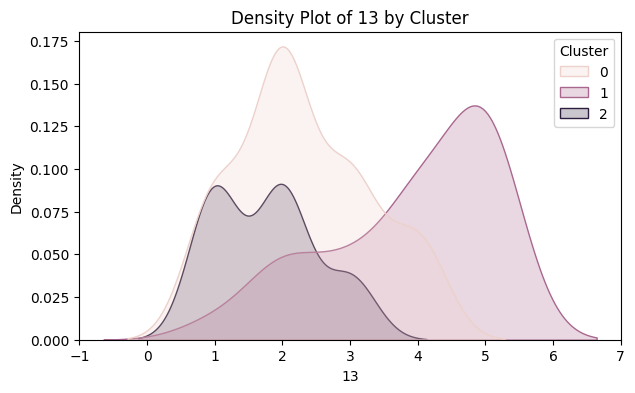

In [ ]:
for col in final_iv_list:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=df, x=col, hue="Cluster", shade=True)
    plt.title(f"Density Plot of {col} by Cluster")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

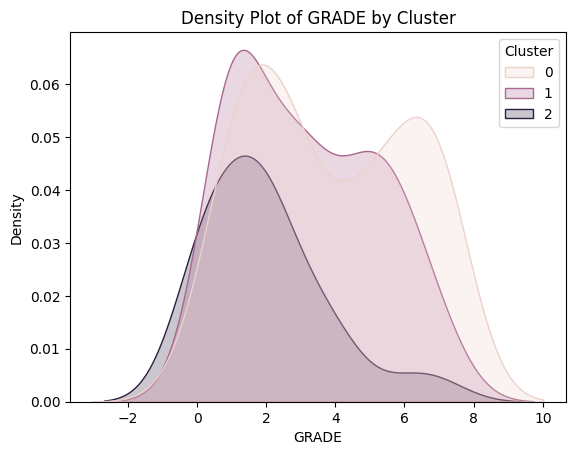

In [ ]:
sns.kdeplot(data=df, x="GRADE", hue="Cluster", shade=True)
plt.title("Density Plot of GRADE by Cluster")
plt.xlabel("GRADE")
plt.ylabel("Density")
plt.show()

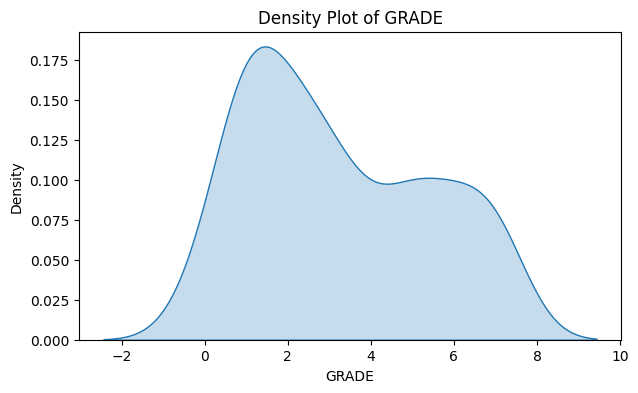

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.kdeplot(df["GRADE"], shade=True)
plt.title("Density Plot of GRADE")
plt.xlabel("GRADE")
plt.ylabel("Density")
plt.show()

Assignment 2

In [ ]:
df = df.copy()

# Remove any old or merged versions
df.drop(columns=['LowGradeFlag'], inplace=True, errors='ignore')

# Recreate correctly
df['LowGradeFlag'] = (df['GRADE'] <= 2).astype(int)

df[['GRADE', 'PassFlag', 'LowGradeFlag']].head(20)


,GRADE,PassFlag,LowGradeFlag
0,1,0,1
1,1,0,1
2,1,0,1
3,1,0,1
4,1,0,1
5,2,0,1
6,5,1,0
7,2,0,1
8,5,1,0
9,0,0,1


In [ ]:
df['LowGradeFlag'].value_counts(normalize=True).round(3)


,proportion
LowGradeFlag,
0,0.538
1,0.462


In [ ]:
counts = df['LowGradeFlag'].value_counts().sort_index()
perc = (counts / len(df) * 100).round(2)

labels = {0: "Not At Risk (GRADE ≥ 3)",
          1: "At Risk (GRADE ≤ 2)"}

output = pd.DataFrame({
    "Label": counts.index.map(labels),
    "Count": counts.values,
    "Percent": perc.values
})

output


,Label,Count,Percent
0,Not At Risk (GRADE ≥ 3),78,53.79
1,At Risk (GRADE ≤ 2),67,46.21


In [ ]:
final_iv_list = ["29", "22", "26", "17", "21", "24", "18", "19"]


In [ ]:
import pandas as pd
import numpy as np # Added for np.sqrt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# -----------------------------
# 1. REGRESSION MODELS (DV = GRADE)
# -----------------------------

X_reg = df[final_iv_list]
y_reg = df['GRADE']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# ---- Model 1: Linear Regression ----
lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)
lin_pred = lin_reg.predict(Xr_test)

# Calculate and assign regression metrics
lin_rmse = np.sqrt(mean_squared_error(yr_test, lin_pred))
lin_mae = mean_absolute_error(yr_test, lin_pred)
lin_r2 = r2_score(yr_test, lin_pred)

print("Linear Regression Results:")
print("RMSE:", lin_rmse)
print("MAE:", lin_mae)
print("R²:", lin_r2)
print("\n")

# ---- Model 2: Random Forest Regressor ----
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(Xr_train, yr_train)
rf_pred = rf_reg.predict(Xr_test)

# Calculate and assign regression metrics
rf_rmse = np.sqrt(mean_squared_error(yr_test, rf_pred))
rf_mae = mean_absolute_error(yr_test, rf_pred)
rf_r2 = r2_score(yr_test, rf_pred)

print("Random Forest Regressor Results:")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R²:", rf_r2)
print("\n")


# -----------------------------
# 2. CLASSIFICATION MODELS (DV = LowGradeFlag)
# -----------------------------

X_clf = df[final_iv_list]
y_clf = df['LowGradeFlag']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# ---- Model 3: Logistic Regression ----
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(Xc_train, yc_train)
log_pred = log_reg.predict(Xc_test)
log_prob = log_reg.predict_proba(Xc_test)[:, 1]

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(yc_test, log_pred))
print("Precision:", precision_score(yc_test, log_pred))
print("Recall:", recall_score(yc_test, log_pred))
print("F1 Score:", f1_score(yc_test, log_pred))
print("ROC-AUC:", roc_auc_score(yc_test, log_prob))
print("\n")

# ---- Model 4: Random Forest Classifier ----
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(Xc_train, yc_train)
rf_pred = rf_clf.predict(Xc_test)
rf_prob = rf_clf.predict_proba(Xc_test)[:, 1]

print("Random Forest Classifier Results:")
print("Accuracy:", accuracy_score(yc_test, rf_pred))
print("Precision:", precision_score(yc_test, rf_pred))
print("Recall:", recall_score(yc_test, rf_pred))
print("F1 Score:", f1_score(yc_test, rf_pred))
print("ROC-AUC:", roc_auc_score(yc_test, rf_prob))

Linear Regression Results:
RMSE: 1.934103960581667
MAE: 1.6017537633889452
R²: 0.1862448040315574


Random Forest Regressor Results:
RMSE: 2.0184354258836605
MAE: 1.6831375205254517
R²: 0.1137344544550768


Logistic Regression Results:
Accuracy: 0.6551724137931034
Precision: 0.5384615384615384
Recall: 0.6363636363636364
F1 Score: 0.5833333333333334
ROC-AUC: 0.7348484848484849


Random Forest Classifier Results:
Accuracy: 0.7241379310344828
Precision: 0.6153846153846154
Recall: 0.7272727272727273
F1 Score: 0.6666666666666666
ROC-AUC: 0.7702020202020201


In [ ]:
# ---- Model 3: Logistic Regression ----
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(Xc_train, yc_train)
log_pred = log_reg.predict(Xc_test)
log_prob = log_reg.predict_proba(Xc_test)[:, 1]

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(yc_test, log_pred))
print("Precision:", precision_score(yc_test, log_pred))
print("Recall:", recall_score(yc_test, log_pred))
print("F1 Score:", f1_score(yc_test, log_pred))
print("ROC-AUC:", roc_auc_score(yc_test, log_prob))
print("\n")

# ---- Model 4: Random Forest Classifier ----
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(Xc_train, yc_train)
rf_pred = rf_clf.predict(Xc_test)
rf_prob = rf_clf.predict_proba(Xc_test)[:, 1]

print("Random Forest Classifier Results:")
print("Accuracy:", accuracy_score(yc_test, rf_pred))
print("Precision:", precision_score(yc_test, rf_pred))
print("Recall:", recall_score(yc_test, rf_pred))
print("F1 Score:", f1_score(yc_test, rf_pred))
print("ROC-AUC:", roc_auc_score(yc_test, rf_prob))


Logistic Regression Results:
Accuracy: 0.6551724137931034
Precision: 0.5384615384615384
Recall: 0.6363636363636364
F1 Score: 0.5833333333333334
ROC-AUC: 0.7348484848484849


Random Forest Classifier Results:
Accuracy: 0.7241379310344828
Precision: 0.6153846153846154
Recall: 0.7272727272727273
F1 Score: 0.6666666666666666
ROC-AUC: 0.7702020202020201


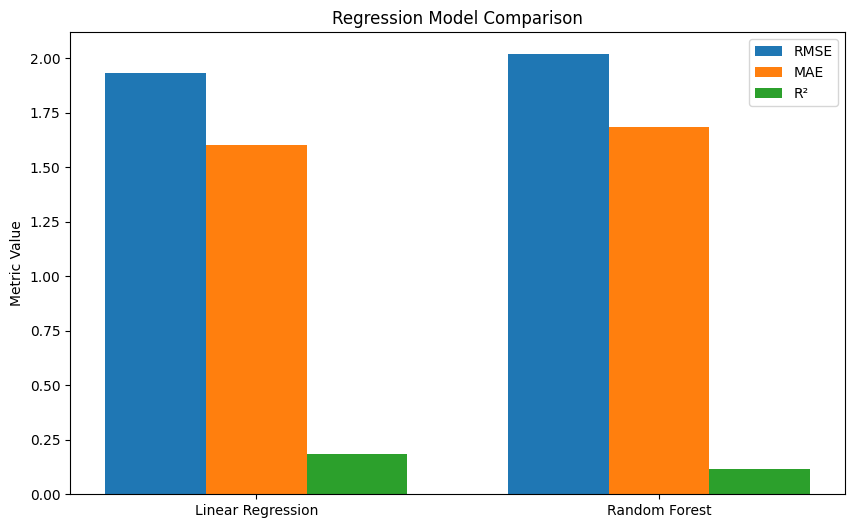

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Regression metrics
reg_models = ['Linear Regression', 'Random Forest']
rmse_vals = [lin_rmse, rf_rmse]
mae_vals = [lin_mae, rf_mae]
r2_vals = [lin_r2, rf_r2]

x = np.arange(len(reg_models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, rmse_vals, width, label='RMSE')
plt.bar(x, mae_vals, width, label='MAE')
plt.bar(x + width, r2_vals, width, label='R²')

plt.xticks(x, reg_models)
plt.ylabel('Metric Value')
plt.title('Regression Model Comparison')
plt.legend()
plt.show()


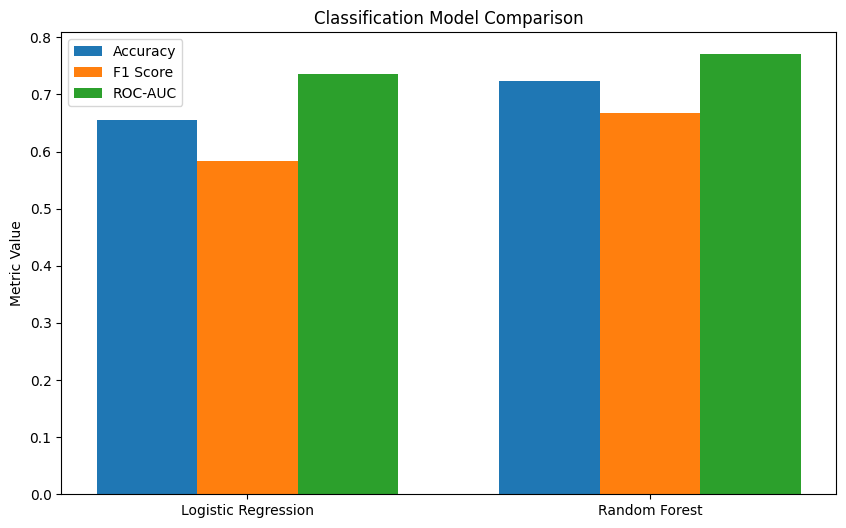

In [ ]:
# Classification metrics
clf_models = ['Logistic Regression', 'Random Forest']
accuracy_vals = [accuracy_score(yc_test, log_pred), accuracy_score(yc_test, rf_pred)]
f1_vals = [f1_score(yc_test, log_pred), f1_score(yc_test, rf_pred)]
auc_vals = [roc_auc_score(yc_test, log_prob), roc_auc_score(yc_test, rf_prob)]

x = np.arange(len(clf_models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, accuracy_vals, width, label='Accuracy')
plt.bar(x, f1_vals, width, label='F1 Score')
plt.bar(x + width, auc_vals, width, label='ROC-AUC')

plt.xticks(x, clf_models)
plt.ylabel('Metric Value')
plt.title('Classification Model Comparison')
plt.legend()
plt.show()


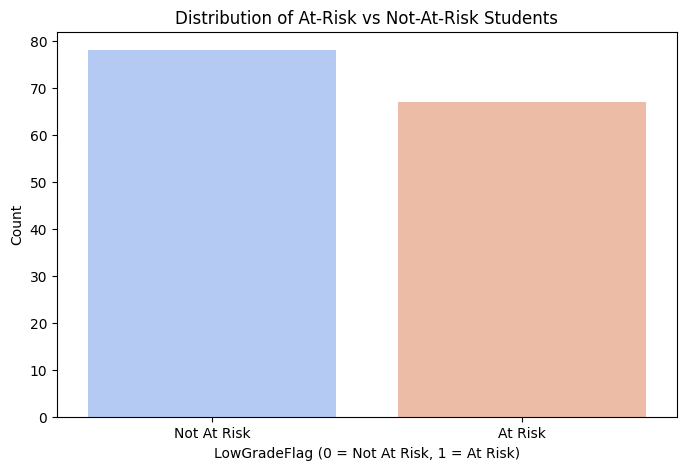

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='LowGradeFlag', data=df, palette='coolwarm')

plt.title('Distribution of At-Risk vs Not-At-Risk Students')
plt.xlabel('LowGradeFlag (0 = Not At Risk, 1 = At Risk)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not At Risk', 'At Risk'])
plt.show()


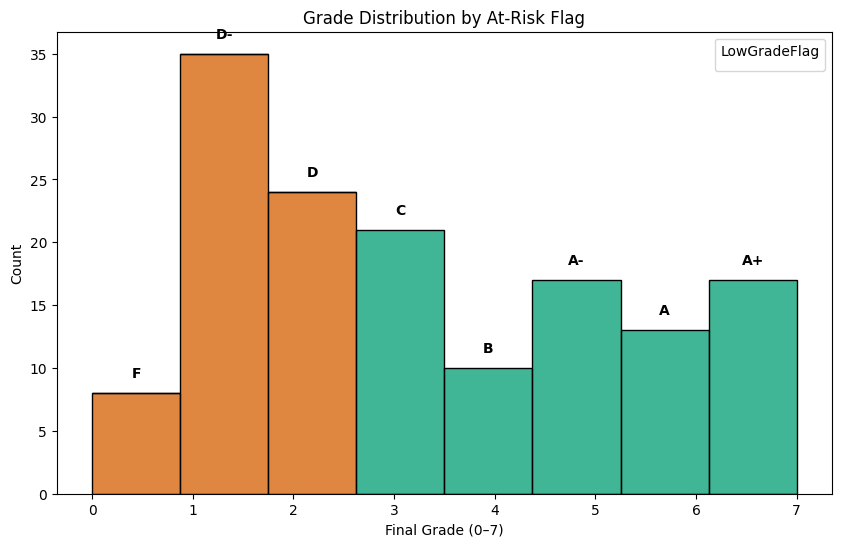

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Recreate the flag cleanly (safe and correct) ---
df = df.copy()
df['LowGradeFlag'] = (df['GRADE'] <= 2).astype(int)

# --- Color-blind-safe palette ---
risk_palette = {
    0: "#009E73",   # Not At Risk (green-teal)
    1: "#D55E00"    # At Risk (red-orange)
}

# --- Numeric → Letter grade mapping ---
grade_labels = {
    0: "F",
    1: "D-",
    2: "D",
    3: "C",
    4: "B",
    5: "A-",
    6: "A",
    7: "A+"
}

plt.figure(figsize=(10,6))

# --- Histogram ---
ax = sns.histplot(
    data=df,
    x='GRADE',
    hue='LowGradeFlag',
    bins=8,
    palette=risk_palette,
    kde=False,
    multiple='stack',
    hue_order=[0, 1]   # ensures correct color order
)

# --- Add letter grade labels above bars ---
labeled_grades = set()

for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        x_pos = patch.get_x() + patch.get_width() / 2
        grade_value = int(round(x_pos))

        if grade_value in grade_labels and grade_value not in labeled_grades:
            ax.text(
                x_pos,
                height + 1,
                grade_labels[grade_value],
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold'
            )
            labeled_grades.add(grade_value)

# --- Fix legend so labels ALWAYS match colors ---
handles, labels = ax.get_legend_handles_labels()
label_map = {
    '0': 'Not At Risk (0)',
    '1': 'At Risk (1)'
}

ax.legend(
    handles=handles,
    labels=[label_map[l] for l in labels],
    title='LowGradeFlag'
)

plt.title('Grade Distribution by At-Risk Flag')
plt.xlabel('Final Grade (0–7)')
plt.ylabel('Count')
plt.show()


Assignment 3


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Supervised Model using same predictors as Assignment 2
X = df[final_iv_list]
y = df['LowGradeFlag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.6363636363636364
Precision: 0.6666666666666666
Recall: 0.6666666666666666
F1 Score: 0.6666666666666666
ROC-AUC: 0.7729166666666666


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = df[final_iv_list]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

sil_score = silhouette_score(scaled_features, df['Cluster'])
print("Silhouette Score:", sil_score)

print(df['Cluster'].value_counts())


Silhouette Score: 0.2257629518668122
Cluster
3    79
2    31
0    19
1    16
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_mixed = df[final_iv_list + ['Cluster']]
y_mixed = df['LowGradeFlag']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mixed, y_mixed, test_size=0.3, random_state=42
)

rf_mixed = RandomForestClassifier(random_state=42)
rf_mixed.fit(X_train_m, y_train_m)

y_pred_m = rf_mixed.predict(X_test_m)
y_prob_m = rf_mixed.predict_proba(X_test_m)[:, 1]

print("Accuracy:", accuracy_score(y_test_m, y_pred_m))
print("Precision:", precision_score(y_test_m, y_pred_m))
print("Recall:", recall_score(y_test_m, y_pred_m))
print("F1 Score:", f1_score(y_test_m, y_pred_m))
print("ROC-AUC:", roc_auc_score(y_test_m, y_prob_m))


Accuracy: 0.6363636363636364
Precision: 0.7
Recall: 0.5833333333333334
F1 Score: 0.6363636363636364
ROC-AUC: 0.7364583333333333


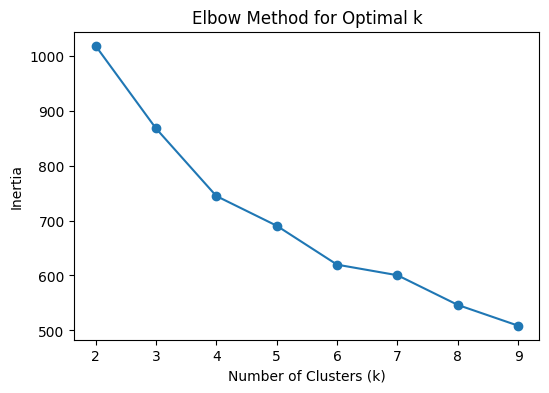

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = df[final_iv_list]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

inertia_values = []
k_values = range(2, 10)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_features)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_values, inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


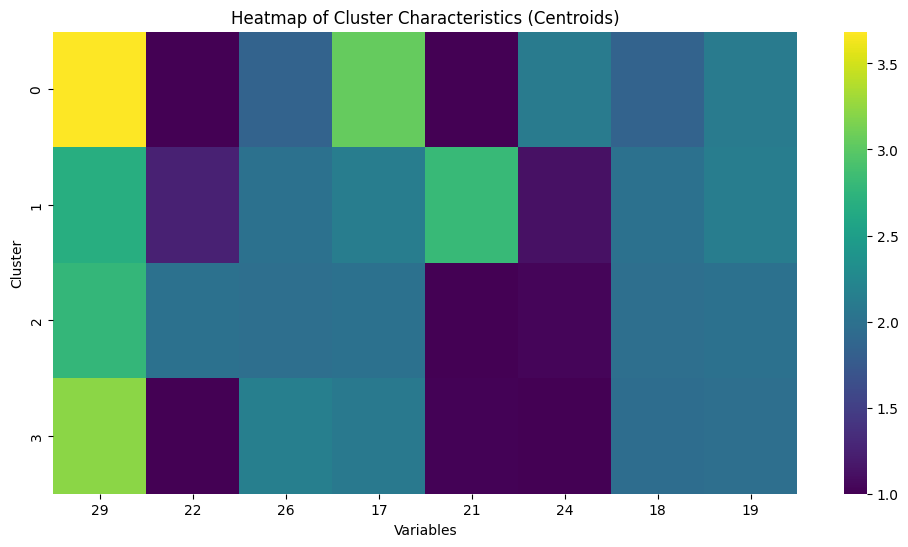

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute cluster centroids
centroids = df.groupby('Cluster')[final_iv_list].mean()

plt.figure(figsize=(12,6))
sns.heatmap(centroids, cmap='viridis', annot=False)
plt.title('Heatmap of Cluster Characteristics (Centroids)')
plt.xlabel('Variables')
plt.ylabel('Cluster')
plt.show()


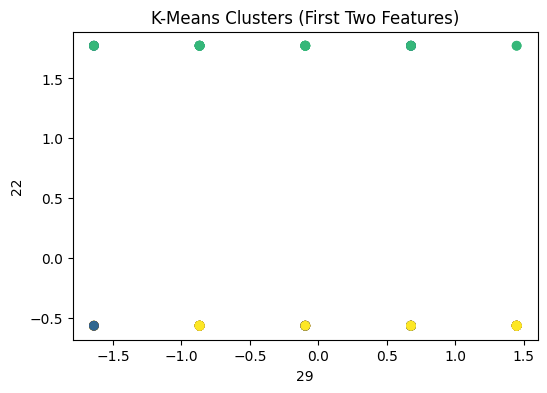

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=df['Cluster'], cmap='viridis')
plt.xlabel(final_iv_list[0])
plt.ylabel(final_iv_list[1])
plt.title('K-Means Clusters (First Two Features)')
plt.show()


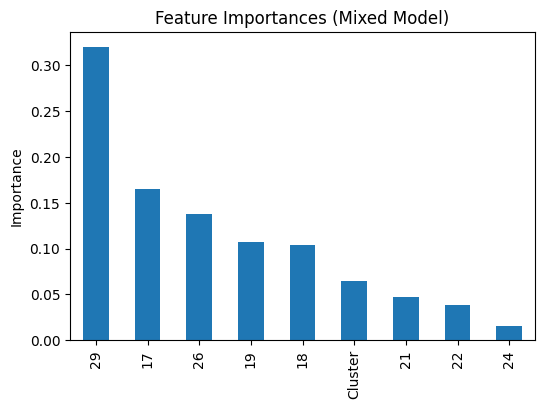

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    rf_mixed.feature_importances_,
    index=X_mixed.columns
).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind='bar')
plt.title('Feature Importances (Mixed Model)')
plt.ylabel('Importance')
plt.show()


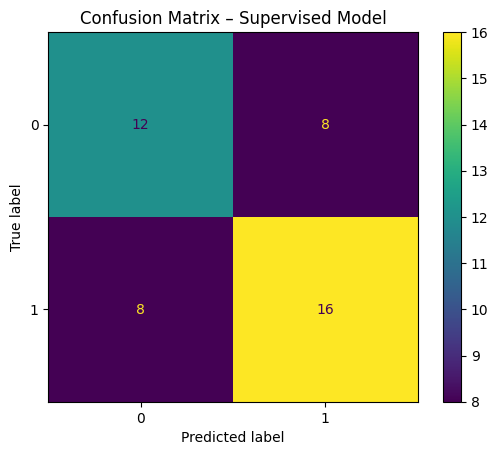

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title('Confusion Matrix – Supervised Model')
plt.show()


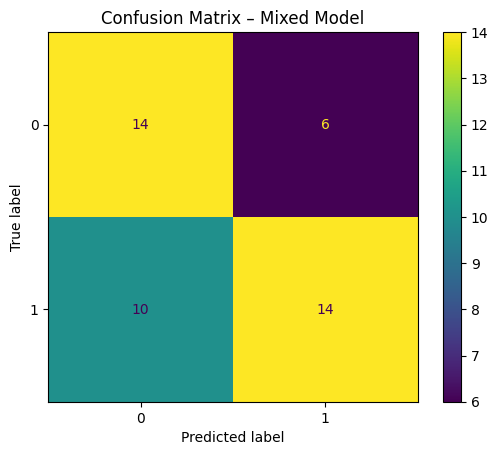

In [ ]:
ConfusionMatrixDisplay.from_estimator(rf_mixed, X_test_m, y_test_m)
plt.title('Confusion Matrix – Mixed Model')
plt.show()


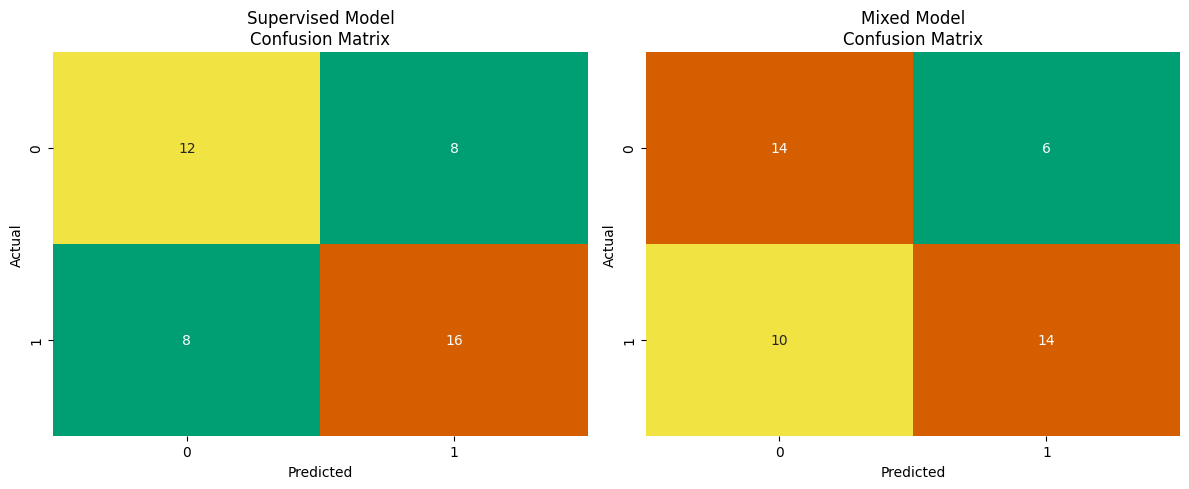

In [ ]:
# -----------------------------
# Supervised model predictions
# -----------------------------
y_pred_supervised = rf.predict(X_test)

# -----------------------------
# Mixed model predictions
# -----------------------------
y_pred_mixed = rf_mixed.predict(X_test_m)

# -----------------------------
# Confusion matrices
# -----------------------------
cm_supervised = confusion_matrix(y_test, y_pred_supervised)
cm_mixed = confusion_matrix(y_test, y_pred_mixed)

# -----------------------------
# Custom green-yellow colormap
# -----------------------------
from matplotlib.colors import LinearSegmentedColormap
green_yellow_dynamic = LinearSegmentedColormap.from_list(
    "green_yellow_dynamic",
    ["#009E73", "#F0E442", "#D55E00"]
)

# -----------------------------
# Side-by-side visualization
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Supervised model matrix
sns.heatmap(cm_supervised, annot=True, fmt='d', cmap=green_yellow_dynamic, cbar=False, ax=axes[0])
axes[0].set_title("Supervised Model\nConfusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Mixed model matrix
sns.heatmap(cm_mixed, annot=True, fmt='d', cmap=green_yellow_dynamic, cbar=False, ax=axes[1])
axes[1].set_title("Mixed Model\nConfusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Microsoft Copilot  
Microsoft. (2024). Microsoft Copilot Help & Learning. https://support.microsoft.com/copilot

Google Gemini (AI Studio / Gemini API)  
Google. (2024). Gemini API Documentation. https://ai.google.dev/

Yilmaz, N. & Şekeroğlu, B. (2019). Higher Education Students Performance Evaluation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C51G82.